In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

np.random.seed(42)

# Create a dense cluster near (lat=35, lon=-120)
cluster_lat = 35 + np.random.normal(0, 0.25, 40)   # ~dense region
cluster_lon = -120 + np.random.normal(0, 0.25, 40)

# Create a few border-ish points slightly further out
border_lat = 35 + np.random.normal(0, 0.55, 10)
border_lon = -120 + np.random.normal(0, 0.55, 10)

# Create isolated noise points far away
noise_lat = np.array([10, -20, 60, 0, 45])
noise_lon = np.array([80, 120, -10, -160, 150])

lat = np.concatenate([cluster_lat, border_lat, noise_lat])
lon = np.concatenate([cluster_lon, border_lon, noise_lon])

demo_df = pd.DataFrame({"latitude": lat, "longitude": lon})
demo_df.head()

,latitude,longitude
0,35.124179,-119.815383
1,34.965434,-119.957158
2,35.161922,-120.028912
3,35.380757,-120.075276
4,34.941462,-120.369630


In [2]:
# Parameters for the example
eps_km = 80
min_samples = 5

# Convert to radians for Haversine
coords_rad = np.radians(demo_df[["latitude", "longitude"]].to_numpy())

# eps in radians (Earth radius ≈ 6371 km)
eps_rad = eps_km / 6371.0088

db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
labels = db.fit_predict(coords_rad)

demo_df["cluster"] = labels

# Core points (from scikit-learn)
core_mask = np.zeros(len(demo_df), dtype=bool)
core_mask[db.core_sample_indices_] = True
demo_df["point_type"] = np.where(labels == -1, "Noise",
                         np.where(core_mask, "Core", "Border"))

print("--- DBSCAN Example Output ---")
print("eps_km =", eps_km, "| min_samples =", min_samples)
print("Clusters found (excluding noise):", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", int((labels == -1).sum()))
print("\nPoint type counts:")
print(demo_df["point_type"].value_counts())

demo_df.head(10)

--- DBSCAN Example Output ---
eps_km = 80 | min_samples = 5
Clusters found (excluding noise): 1
Noise points: 5

Point type counts:
point_type
Core     50
Noise     5
Name: count, dtype: int64


,latitude,longitude,cluster,point_type
0,35.124179,-119.815383,0,Core
1,34.965434,-119.957158,0,Core
2,35.161922,-120.028912,0,Core
3,35.380757,-120.075276,0,Core
4,34.941462,-120.369630,0,Core
5,34.941466,-120.179961,0,Core
6,35.394803,-120.115160,0,Core
7,35.191859,-119.735719,0,Core
8,34.882631,-119.914095,0,Core
9,35.135640,-120.440760,0,Core


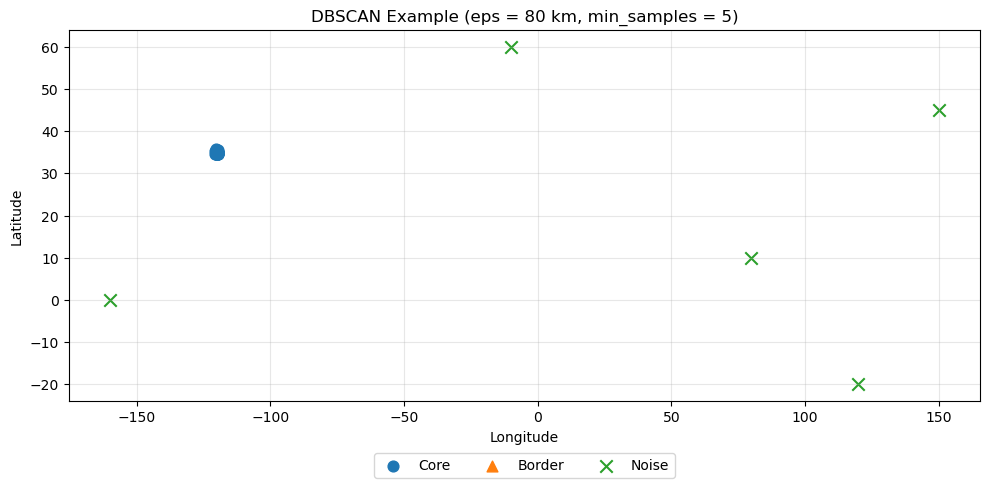

In [4]:
plt.figure(figsize=(10, 5))

core = demo_df[demo_df["point_type"] == "Core"]
border = demo_df[demo_df["point_type"] == "Border"]
noise = demo_df[demo_df["point_type"] == "Noise"]

plt.scatter(core["longitude"], core["latitude"], s=60, marker="o", label="Core")
plt.scatter(border["longitude"], border["latitude"], s=60, marker="^", label="Border")
plt.scatter(noise["longitude"], noise["latitude"], s=80, marker="x", label="Noise")

plt.title("DBSCAN Example (eps = 80 km, min_samples = 5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Choose k (usually equal to min_samples)
k = 4  # change to 5/10/etc if you want

# Fit k-NN on radians coordinates (Haversine)
nn = NearestNeighbors(n_neighbors=k, metric="haversine")
nn.fit(coords_rad)

# distances: each row = distances to k neighbors (including itself as nearest)
distances, _ = nn.kneighbors(coords_rad)

# k-distance = distance to k-th nearest neighbor
k_dist = distances[:, -1]  # in radians

# Convert radians to km for easy interpretation
EARTH_RADIUS_KM = 6371.0088
k_dist_km = k_dist * EARTH_RADIUS_KM

# Sort distances for elbow analysis
k_dist_sorted = np.sort(k_dist_km)

# Create Sorted Index vs k-distance table
kdist_table = pd.DataFrame({
    "Sorted Index (x-axis)": np.arange(len(k_dist_sorted)),
    f"{k}th NN Distance (km) (y-axis)": k_dist_sorted
})

# Show a small sample (top rows like the example)
kdist_table.head(15)

,Sorted Index (x-axis),4th NN Distance (km) (y-axis)
0,0,3.669293
1,1,3.909549
2,2,3.909549
3,3,3.937332
4,4,4.695686
5,5,6.817080
6,6,8.490514
7,7,9.390590
8,8,9.639077
9,9,9.838867


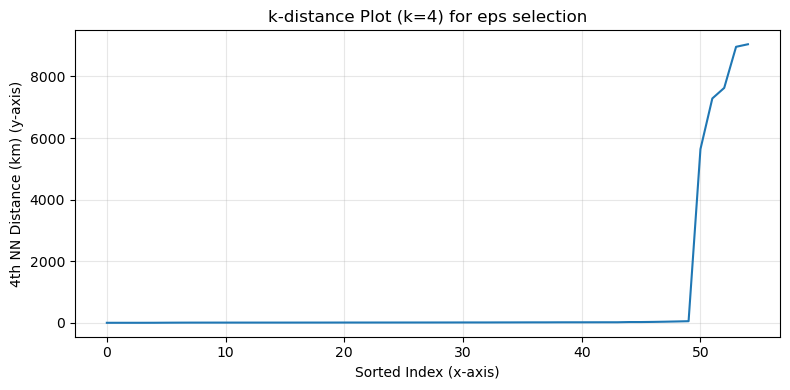

In [6]:
plt.figure(figsize=(8,4))
plt.plot(kdist_table["Sorted Index (x-axis)"], kdist_table.iloc[:, 1])
plt.title(f"k-distance Plot (k={k}) for eps selection")
plt.xlabel("Sorted Index (x-axis)")
plt.ylabel(f"{k}th NN Distance (km) (y-axis)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()